# OPC

In [ ]:
# Uninstall conflicting packages

# Install compatible versions
!pip install numpy==1.24.4  # Critical for CatBoost compatibility
!pip install catboost==1.2.7
!pip install tensorflow==2.12.0  # Optional (if you need TF)

# Force restart the runtime (essential!)
import os
os.kill(os.getpid(), 9)  # Or manually restart via Colab's UI

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 83.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blosc2 3.2.1 requires numpy>=1.26, but you have numpy 1.24.4 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
pymc 5.21.1 requires numpy>=1.25.0, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.0 MB/s eta 0:00:00
   ━━━

In [1]:
from catboost import CatBoostClassifier


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
from sklearn.decomposition import PCA


In [17]:
df = pd.read_excel('CRACK DETECTION TRAIL FEB 2025.xlsx')

X = df.drop(columns=['Conductance At FAILURE']).values
y = df['Conductance At FAILURE'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)


In [18]:
initial_threshold = 0.7
Target_mean = df['Conductance At FAILURE'].mean()
Target_std = df['Conductance At FAILURE'].std()
print(f" At FAILURE Mean: {Target_mean}")
print(f"Conductance At FAILURE Deviation: {Target_std}")
adjusted_threshold = Target_mean + Target_std

y_binary = np.where(y > adjusted_threshold, 1, 0)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_binary, test_size=0.2, random_state=42)

 At FAILURE Mean: 0.6379620695513004
Conductance At FAILURE Deviation: 2.468065131850027


In [19]:
input_dim = X_train.shape[1]
encoding_dim = 16

In [25]:
input_layer = Input(shape=(input_dim,))
x = Dense(64)(input_layer)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Dropout(0.2)(x)
x = Dense(32)(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
encoded = Dense(encoding_dim, activation="linear")(x)  # Bottleneck layer

x = Dense(32)(encoded)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Dense(64)(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
decoded = Dense(input_dim, activation="linear")(x)

In [26]:
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

In [27]:
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss="mse")
autoencoder.fit(X_train, X_train, epochs=100, batch_size=16, shuffle=True, validation_data=(X_test, X_test))

Epoch 1/100
5/5 [==============================] - 3s 74ms/step - loss: 5.7694 - val_loss: 0.7692
Epoch 2/100
5/5 [==============================] - 0s 17ms/step - loss: 6.1585 - val_loss: 0.7308
Epoch 3/100
5/5 [==============================] - 0s 12ms/step - loss: 4.7186 - val_loss: 0.6899
Epoch 4/100
5/5 [==============================] - 0s 12ms/step - loss: 4.2512 - val_loss: 0.6509
Epoch 5/100
5/5 [==============================] - 0s 12ms/step - loss: 3.6754 - val_loss: 0.6146
Epoch 6/100
5/5 [==============================] - 0s 16ms/step - loss: 3.4760 - val_loss: 0.5823
Epoch 7/100
5/5 [==============================] - 0s 16ms/step - loss: 4.3383 - val_loss: 0.5509
Epoch 8/100
5/5 [==============================] - 0s 15ms/step - loss: 3.0877 - val_loss: 0.5242
Epoch 9/100
5/5 [==============================] - 0s 11ms/step - loss: 3.4178 - val_loss: 0.4967
Epoch 10/100
5/5 [==============================] - 0s 16ms/step - loss: 3.8595 - val_loss: 0.4750
Epoch 11/100
5/5 [=

In [28]:
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

1/1 [==============================] - 0s 21ms/step


In [29]:
catboost_model = CatBoostClassifier(iterations=1000, depth=6, learning_rate=0.03, loss_function='Logloss', verbose=100)
catboost_model.fit(X_train_encoded, y_train)

0:	learn: 0.6406820	total: 54.7ms	remaining: 54.7s
100:	learn: 0.0175255	total: 216ms	remaining: 1.93s
200:	learn: 0.0065122	total: 401ms	remaining: 1.59s
300:	learn: 0.0040638	total: 575ms	remaining: 1.33s
400:	learn: 0.0031083	total: 760ms	remaining: 1.14s
500:	learn: 0.0025329	total: 948ms	remaining: 944ms
600:	learn: 0.0021214	total: 1.12s	remaining: 741ms
700:	learn: 0.0018287	total: 1.28s	remaining: 548ms
800:	learn: 0.0015832	total: 1.45s	remaining: 361ms
900:	learn: 0.0013940	total: 1.63s	remaining: 179ms
999:	learn: 0.0012459	total: 1.97s	remaining: 0us


In [31]:
# prompt: classification table

from sklearn.metrics import classification_report, confusion_matrix

y_pred = catboost_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       0.00      0.00      0.00         1

    accuracy                           0.95        20
   macro avg       0.47      0.50      0.49        20
weighted avg       0.90      0.95      0.93        20

[[19  0]
 [ 1  0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


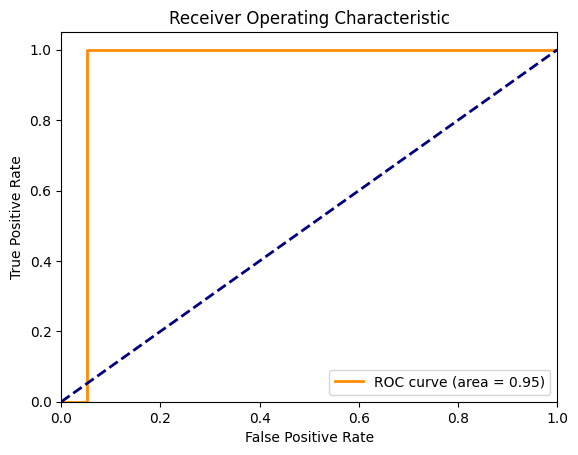

In [32]:
# prompt: roc curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ... (Your existing code) ...

y_pred_proba = catboost_model.predict_proba(X_test_encoded)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


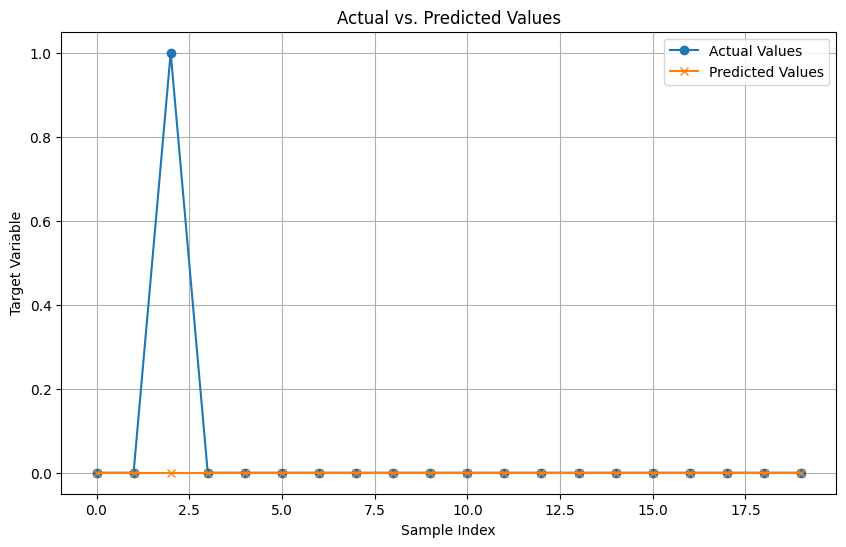

In [34]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Values', marker='o')
plt.plot(y_pred, label='Predicted Values', marker='x')
plt.xlabel('Sample Index')
plt.ylabel('Target Variable')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)
plt.show()


In [44]:
# prompt: give cracked value and predict crack or not from the model

import numpy as np
# Assuming 'cracked_value' is a single data point or an array of data points
# that needs to be preprocessed (scaled and PCA-transformed) in the same way as the training data.


# cracked_value should have the same number of features as the original data (11 in this case)
cracked_value = np.array([[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]]) # Example: Adjusted cracked_value with 11 features. Replace with your actual cracked value ensuring it has the correct number of features


# Preprocess the cracked value
cracked_value_scaled = scaler.transform(cracked_value)
cracked_value_pca = pca.transform(cracked_value_scaled)

# Encode using the trained encoder
cracked_value_encoded = encoder.predict(cracked_value_pca)

# Predict using the trained CatBoost model
prediction = catboost_model.predict(cracked_value_encoded)


# Interpretation
if prediction[0] == 1:
  print("The model predicts a crack.")
else:
  print("The model predicts no crack.")

1/1 [==============================] - 0s 45ms/step
The model predicts no crack.


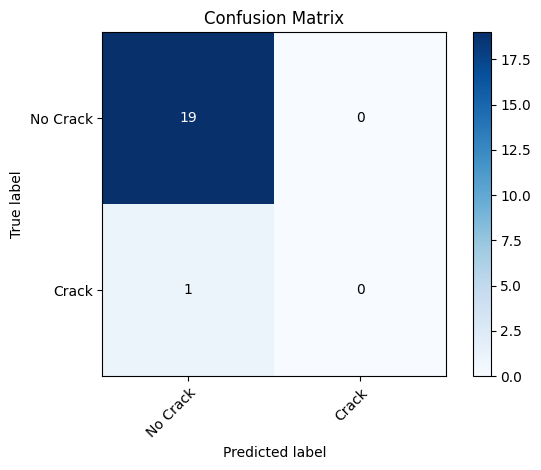

In [46]:
# prompt: print classification matrix with labels\

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# ... (Your existing code) ...

# Assuming y_test and y_pred are defined as before


cm = confusion_matrix(y_test, y_pred)

# Define class labels (replace with your actual labels)
class_names = ['No Crack', 'Crack']


fig, ax = plt.subplots()
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Show all ticks and label them with the respective list entries
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names, yticklabels=class_names,
       title='Confusion Matrix',
       ylabel='True label',
       xlabel='Predicted label')

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
fmt = 'd'
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], fmt),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
fig.tight_layout()
plt.show()


# PPC

In [47]:
df = pd.read_excel('PPC CRACK DETECTION 2025.xlsx')

X = df.drop(columns=['FAILURE']).values
y = df['FAILURE'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)


In [49]:
initial_threshold = 0.7
Target_mean = df['FAILURE'].mean()
Target_std = df['FAILURE'].std()
print(f" At FAILURE Mean: {Target_mean}")
print(f"Conductance At FAILURE Deviation: {Target_std}")
adjusted_threshold = Target_mean + Target_std

y_binary = np.where(y > adjusted_threshold, 1, 0)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_binary, test_size=0.2, random_state=42)

 At FAILURE Mean: 0.627511151596762
Conductance At FAILURE Deviation: 1.3081286727182357


In [50]:
input_dim = X_train.shape[1]
encoding_dim = 16

In [51]:
input_layer = Input(shape=(input_dim,))
x = Dense(64)(input_layer)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Dropout(0.2)(x)
x = Dense(32)(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
encoded = Dense(encoding_dim, activation="linear")(x)  # Bottleneck layer

x = Dense(32)(encoded)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Dense(64)(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
decoded = Dense(input_dim, activation="linear")(x)

In [52]:
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

In [53]:
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss="mse")
autoencoder.fit(X_train, X_train, epochs=100, batch_size=16, shuffle=True, validation_data=(X_test, X_test))

Epoch 1/100
5/5 [==============================] - 3s 67ms/step - loss: 3.0678 - val_loss: 6.2867
Epoch 2/100
5/5 [==============================] - 0s 16ms/step - loss: 2.2720 - val_loss: 5.9108
Epoch 3/100
5/5 [==============================] - 0s 13ms/step - loss: 1.9425 - val_loss: 5.5146
Epoch 4/100
5/5 [==============================] - 0s 13ms/step - loss: 1.5115 - val_loss: 5.1838
Epoch 5/100
5/5 [==============================] - 0s 13ms/step - loss: 1.5414 - val_loss: 4.7891
Epoch 6/100
5/5 [==============================] - 0s 13ms/step - loss: 0.9902 - val_loss: 4.4262
Epoch 7/100
5/5 [==============================] - 0s 12ms/step - loss: 1.3670 - val_loss: 4.0975
Epoch 8/100
5/5 [==============================] - 0s 17ms/step - loss: 1.3083 - val_loss: 3.8743
Epoch 9/100
5/5 [==============================] - 0s 16ms/step - loss: 1.2440 - val_loss: 3.6807
Epoch 10/100
5/5 [==============================] - 0s 12ms/step - loss: 0.9676 - val_loss: 3.4552
Epoch 11/100
5/5 [=

In [54]:
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

1/1 [==============================] - 0s 39ms/step


In [55]:
catboost_model = CatBoostClassifier(iterations=1000, depth=6, learning_rate=0.03, loss_function='Logloss', verbose=100)
catboost_model.fit(X_train_encoded, y_train)

0:	learn: 0.6374239	total: 6.71ms	remaining: 6.7s
100:	learn: 0.0208154	total: 678ms	remaining: 6.03s
200:	learn: 0.0075046	total: 1.44s	remaining: 5.72s
300:	learn: 0.0043859	total: 2.16s	remaining: 5.03s
400:	learn: 0.0031289	total: 2.69s	remaining: 4.02s
500:	learn: 0.0024488	total: 3.08s	remaining: 3.06s
600:	learn: 0.0020138	total: 3.28s	remaining: 2.18s
700:	learn: 0.0017068	total: 3.46s	remaining: 1.47s
800:	learn: 0.0014802	total: 3.63s	remaining: 901ms
900:	learn: 0.0013135	total: 3.81s	remaining: 418ms
999:	learn: 0.0011857	total: 3.98s	remaining: 0us


In [56]:
# prompt: classification table

from sklearn.metrics import classification_report, confusion_matrix

y_pred = catboost_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00         1

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

[[19  0]
 [ 0  1]]


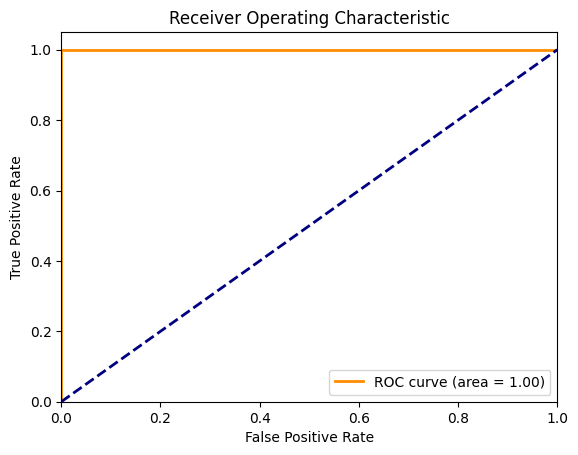

In [57]:
# prompt: roc curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ... (Your existing code) ...

y_pred_proba = catboost_model.predict_proba(X_test_encoded)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


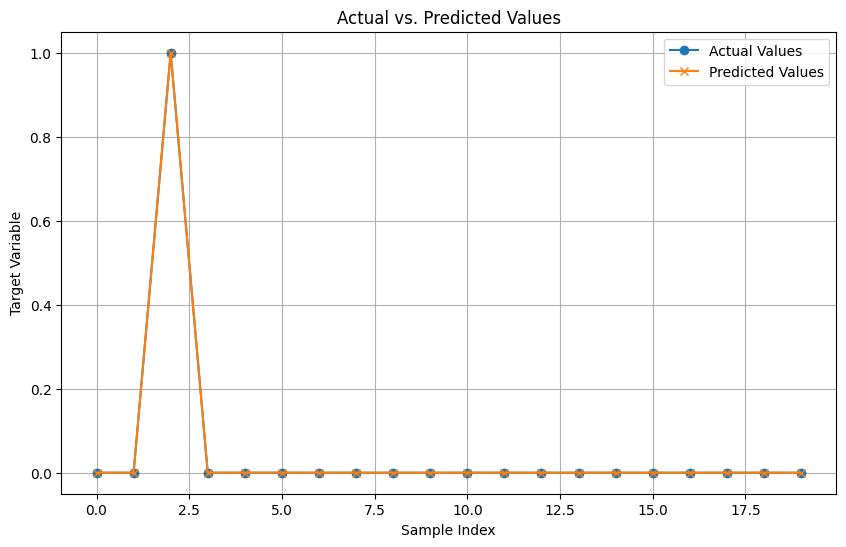

In [58]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Values', marker='o')
plt.plot(y_pred, label='Predicted Values', marker='x')
plt.xlabel('Sample Index')
plt.ylabel('Target Variable')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)
plt.show()


In [60]:
# prompt: give cracked value and predict crack or not from the model

import numpy as np
# Assuming 'cracked_value' is a single data point or an array of data points
# that needs to be preprocessed (scaled and PCA-transformed) in the same way as the training data.


# cracked_value should have the same number of features as the original data (11 in this case)
cracked_value = np.array([[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 7.8, 0.9, 1.0, 1.1]]) # Example: Adjusted cracked_value with 11 features. Replace with your actual cracked value ensuring it has the correct number of features


# Preprocess the cracked value
cracked_value_scaled = scaler.transform(cracked_value)
cracked_value_pca = pca.transform(cracked_value_scaled)

# Encode using the trained encoder
cracked_value_encoded = encoder.predict(cracked_value_pca)

# Predict using the trained CatBoost model
prediction = catboost_model.predict(cracked_value_encoded)


# Interpretation
if prediction[0] == 1:
  print("The model predicts a crack.")
else:
  print("The model predicts no crack.")

1/1 [==============================] - 0s 37ms/step
The model predicts no crack.


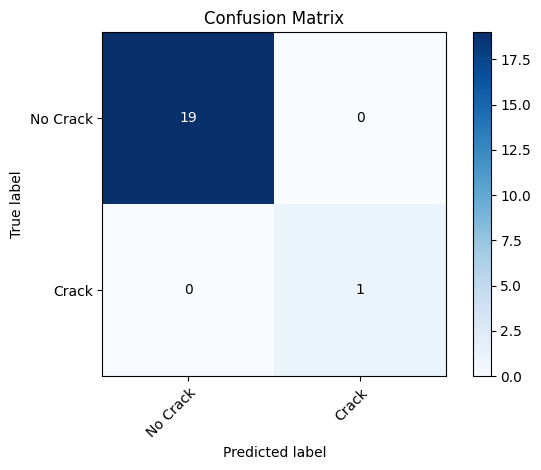

In [61]:
# prompt: print classification matrix with labels\

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# ... (Your existing code) ...

# Assuming y_test and y_pred are defined as before


cm = confusion_matrix(y_test, y_pred)

# Define class labels (replace with your actual labels)
class_names = ['No Crack', 'Crack']


fig, ax = plt.subplots()
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Show all ticks and label them with the respective list entries
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names, yticklabels=class_names,
       title='Confusion Matrix',
       ylabel='True label',
       xlabel='Predicted label')

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
fmt = 'd'
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], fmt),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
fig.tight_layout()
plt.show()


# FRC

In [65]:
df1 = pd.read_excel('PPC CRACK DETECTION 2025.xlsx')

X = df.drop(columns=['FAILURE']).values
y = df['FAILURE'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)


In [66]:
initial_threshold = 0.7
Target_mean = df1['FAILURE'].mean()
Target_std = df1['FAILURE'].std()
print(f" At FAILURE Mean: {Target_mean}")
print(f"Conductance At FAILURE Deviation: {Target_std}")
adjusted_threshold = Target_mean + Target_std

y_binary = np.where(y > adjusted_threshold, 1, 0)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_binary, test_size=0.2, random_state=42)

 At FAILURE Mean: 0.627511151596762
Conductance At FAILURE Deviation: 1.3081286727182357


In [67]:
input_dim = X_train.shape[1]
encoding_dim = 16

In [68]:
input_layer = Input(shape=(input_dim,))
x = Dense(64)(input_layer)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Dropout(0.2)(x)
x = Dense(32)(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
encoded = Dense(encoding_dim, activation="linear")(x)  # Bottleneck layer

x = Dense(32)(encoded)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Dense(64)(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
decoded = Dense(input_dim, activation="linear")(x)

In [69]:
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

In [70]:
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss="mse")
autoencoder.fit(X_train, X_train, epochs=100, batch_size=16, shuffle=True, validation_data=(X_test, X_test))

Epoch 1/100
5/5 [==============================] - 3s 66ms/step - loss: 4.2582 - val_loss: 7.3605
Epoch 2/100
5/5 [==============================] - 0s 15ms/step - loss: 3.5066 - val_loss: 7.1042
Epoch 3/100
5/5 [==============================] - 0s 12ms/step - loss: 2.7341 - val_loss: 6.8234
Epoch 4/100
5/5 [==============================] - 0s 16ms/step - loss: 1.9858 - val_loss: 6.5660
Epoch 5/100
5/5 [==============================] - 0s 16ms/step - loss: 2.2762 - val_loss: 6.2997
Epoch 6/100
5/5 [==============================] - 0s 15ms/step - loss: 2.6996 - val_loss: 5.9903
Epoch 7/100
5/5 [==============================] - 0s 12ms/step - loss: 1.7690 - val_loss: 5.6705
Epoch 8/100
5/5 [==============================] - 0s 11ms/step - loss: 1.5725 - val_loss: 5.2964
Epoch 9/100
5/5 [==============================] - 0s 13ms/step - loss: 1.7658 - val_loss: 5.0053
Epoch 10/100
5/5 [==============================] - 0s 12ms/step - loss: 1.5407 - val_loss: 4.6777
Epoch 11/100
5/5 [=

In [71]:
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

1/1 [==============================] - 0s 33ms/step


In [72]:
catboost_model = CatBoostClassifier(iterations=1000, depth=6, learning_rate=0.03, loss_function='Logloss', verbose=100)
catboost_model.fit(X_train_encoded, y_train)

0:	learn: 0.6454244	total: 2.06ms	remaining: 2.06s
100:	learn: 0.0200810	total: 640ms	remaining: 5.69s
200:	learn: 0.0073555	total: 894ms	remaining: 3.55s
300:	learn: 0.0041528	total: 1.37s	remaining: 3.18s
400:	learn: 0.0029179	total: 2.17s	remaining: 3.25s
500:	learn: 0.0022885	total: 2.92s	remaining: 2.91s
600:	learn: 0.0018208	total: 3.67s	remaining: 2.43s
700:	learn: 0.0015283	total: 4.35s	remaining: 1.86s
800:	learn: 0.0013219	total: 4.57s	remaining: 1.14s
900:	learn: 0.0011636	total: 4.97s	remaining: 546ms
999:	learn: 0.0010445	total: 5.58s	remaining: 0us


In [73]:
# prompt: classification table

from sklearn.metrics import classification_report, confusion_matrix

y_pred = catboost_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00         1

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

[[19  0]
 [ 0  1]]


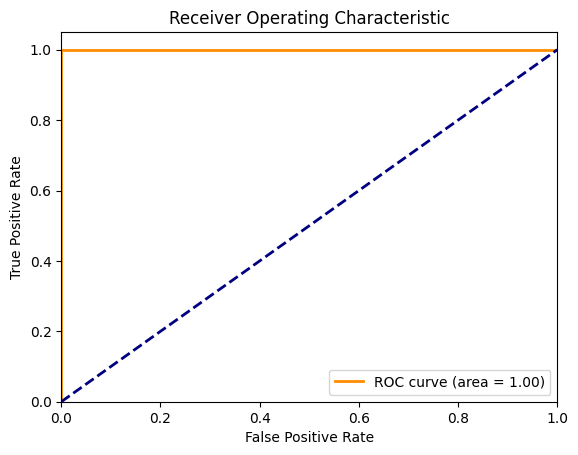

In [74]:
# prompt: roc curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ... (Your existing code) ...

y_pred_proba = catboost_model.predict_proba(X_test_encoded)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


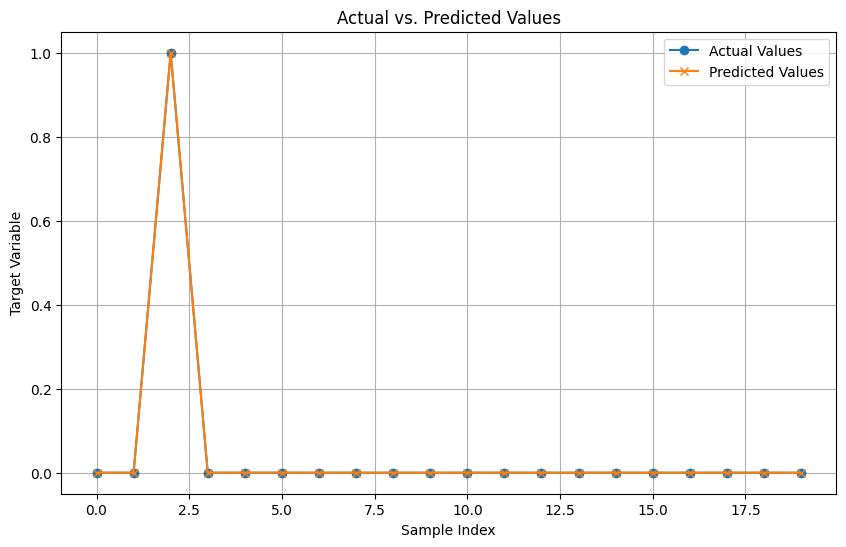

In [75]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Values', marker='o')
plt.plot(y_pred, label='Predicted Values', marker='x')
plt.xlabel('Sample Index')
plt.ylabel('Target Variable')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)
plt.show()


In [81]:
# prompt: give random cracked value, predict crack or not from model

import numpy as np
# Assuming 'cracked_value' is a single data point or an array of data points
# that needs to be preprocessed (scaled and PCA-transformed) in the same way as the training data.

# Example:  A random cracked value with 11 features.
# Replace with your actual cracked value.
cracked_value = np.random.rand(1, 11)

# Preprocess the cracked value
cracked_value_scaled = scaler.transform(cracked_value)
cracked_value_pca = pca.transform(cracked_value_scaled)

# Encode using the trained encoder
cracked_value_encoded = encoder.predict(cracked_value_pca)

# Predict using the trained CatBoost model
prediction = catboost_model.predict(cracked_value_encoded)

# Interpretation
if prediction[0] == 1:
  print("The model predicts a crack.")
else:
  print("The model predicts no crack.")


1/1 [==============================] - 0s 30ms/step
The model predicts no crack.


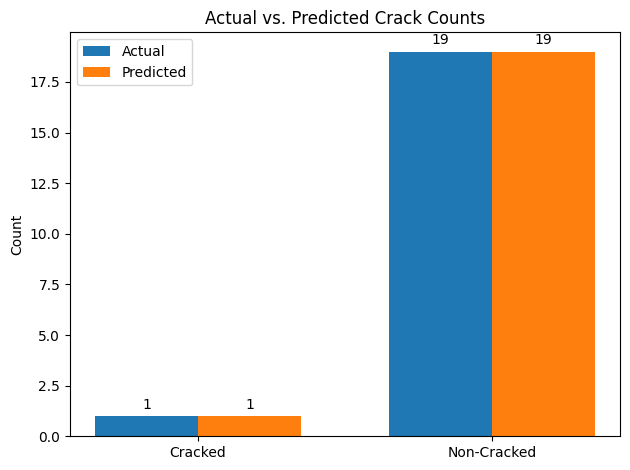

In [85]:
# prompt: bar plot between crack and non cracked values

import matplotlib.pyplot as plt

# Assuming y_test and y_pred are already defined from your model's predictions
# ... (Your existing code) ...

# Count cracked and non-cracked instances in y_test and y_pred
cracked_actual = sum(y_test)
non_cracked_actual = len(y_test) - cracked_actual
cracked_predicted = sum(y_pred)
non_cracked_predicted = len(y_pred) - cracked_predicted

# Create the bar plot
categories = ['Cracked', 'Non-Cracked']
actual_values = [cracked_actual, non_cracked_actual]
predicted_values = [cracked_predicted, non_cracked_predicted]

x = range(len(categories))
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x, actual_values, width, label='Actual')
rects2 = ax.bar([i + width for i in x], predicted_values, width, label='Predicted')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Count')
ax.set_title('Actual vs. Predicted Crack Counts')
ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(categories)
ax.legend()


def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()
